## 1. Import Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

## 2. Data Collection

In [2]:
college_data = pd.read_csv("college_list.csv")
college_data.head()

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9


## 3. Data Understanding

In [4]:
college_data.shape

(500, 6)

In [5]:
college_data.isna().sum()

College_Name             0
Student_Faculty_Ratio    0
Annual_Fees_INR          0
Placement_Percentage     0
Average_Package_LPA      0
Infrastructure_Score     0
dtype: int64

In [8]:
college_data["College_Name"]

0       Indian Institute of Technology Madras - Campus 1
1      National Institute of Technology Trichy - Camp...
2                     Anna University Chennai - Campus 1
3                   PSG College of Technology - Campus 1
4          Coimbatore Institute of Technology - Campus 1
                             ...                        
495       Thiagarajar College of Engineering - Campus 17
496    Bannari Amman Institute of Technology - Campus 17
497    Sri Krishna College of Engineering and Technol...
498               Sona College of Technology - Campus 17
499          Karpagam College of Engineering - Campus 17
Name: College_Name, Length: 500, dtype: object

In [32]:
college_data["College_Name"].unique()

array(['Indian Institute of Technology Madras - Campus 1',
       'National Institute of Technology Trichy - Campus 1',
       'Anna University Chennai - Campus 1',
       'PSG College of Technology - Campus 1',
       'Coimbatore Institute of Technology - Campus 1',
       'Government College of Technology Coimbatore - Campus 1',
       'SSN College of Engineering - Campus 1',
       'SRM Institute of Science and Technology - Campus 1',
       'VIT Vellore - Campus 1', 'SASTRA University - Campus 1',
       'Sri Sairam Engineering College - Campus 1',
       'Velammal Engineering College - Campus 1',
       'Rajalakshmi Engineering College - Campus 1',
       'St Josephs College of Engineering - Campus 1',
       'Kumaraguru College of Technology - Campus 1',
       'Thiagarajar College of Engineering - Campus 1',
       'Bannari Amman Institute of Technology - Campus 1',
       'Sri Krishna College of Engineering and Technology - Campus 1',
       'Sona College of Technology - Campus

In [9]:
college_data.describe()

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
count,500.000000,500.000000,500.000000,500.000000,500.00000
mean,18.084000,138763.710000,69.000000,6.991720,5.97600
std,6.683283,63928.678815,17.193465,2.917991,2.00486
min,8.000000,30404.000000,40.000000,2.000000,3.00000
25%,12.000000,82610.500000,53.750000,4.472500,4.00000
50%,18.000000,140290.500000,69.000000,7.155000,6.00000
75%,24.000000,193422.000000,84.000000,9.432500,8.00000
max,29.000000,249930.000000,99.000000,11.990000,9.00000


## 4. Data Preparation

### 4.1 Delete Unnecessary Features

In [3]:
X = college_data.drop("College_Name", axis=1)
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,14,113042,59,9.20,8
1,27,115999,67,3.07,7
2,22,47955,50,3.40,9
3,18,67841,43,4.64,8
4,15,100640,54,4.66,9
...,...,...,...,...,...
495,17,106323,56,9.33,5
496,12,39111,76,3.62,7
497,16,199182,64,3.88,3
498,10,46389,77,9.31,6


## 4.2 Applying Data Transformation Techniques

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled)
X_scaled

,0,1,2,3,4
0,-0.611689,-0.402753,-0.582199,0.757539,1.010558
1,1.335411,-0.356452,-0.116440,-1.345326,0.511270
2,0.586526,-1.421892,-1.106178,-1.232121,1.509845
3,-0.012581,-1.110515,-1.513717,-0.806745,1.010558
4,-0.461912,-0.596945,-0.873298,-0.799884,1.509845
...,...,...,...,...,...
495,-0.162358,-0.507960,-0.756858,0.802135,-0.487305
496,-0.911243,-1.560372,0.407539,-1.156651,0.511270
497,-0.312135,0.946035,-0.291099,-1.067459,-1.485880
498,-1.210797,-1.446412,0.465759,0.795274,0.011983


In [21]:
X_scaled.mean().round(4),X_scaled.std().round(4)

(0    0.0
 1    0.0
 2   -0.0
 3    0.0
 4   -0.0
 dtype: float64,
 0    1.001
 1    1.001
 2    1.001
 3    1.001
 4    1.001
 dtype: float64)

## 5. Model Building

###  Step 1: Let's check DENDOGRAM

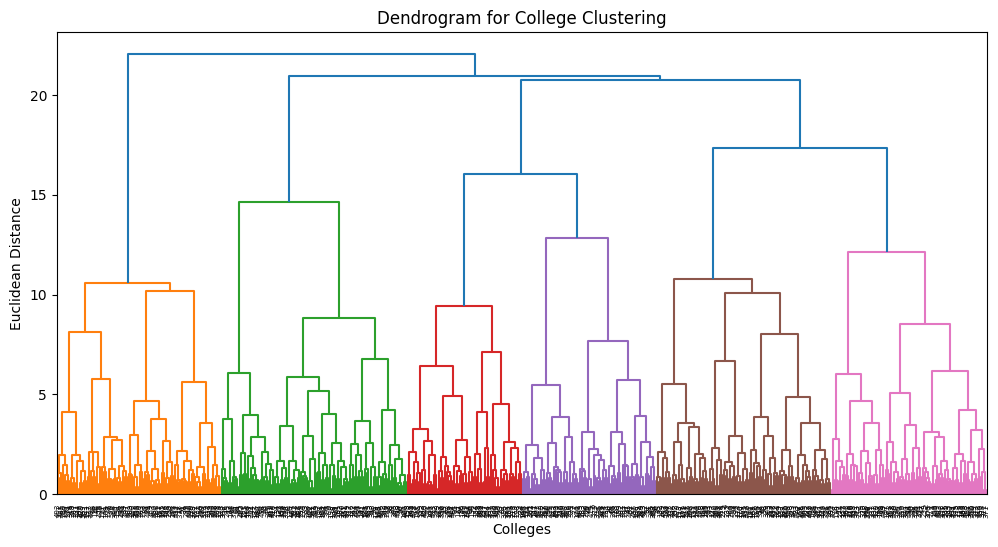

In [6]:
plt.figure(figsize=(12,6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrogram for College Clustering")
plt.xlabel("Colleges")
plt.ylabel("Euclidean Distance")
plt.show()

### For understanding purpose take only 20 colleges to visualize 

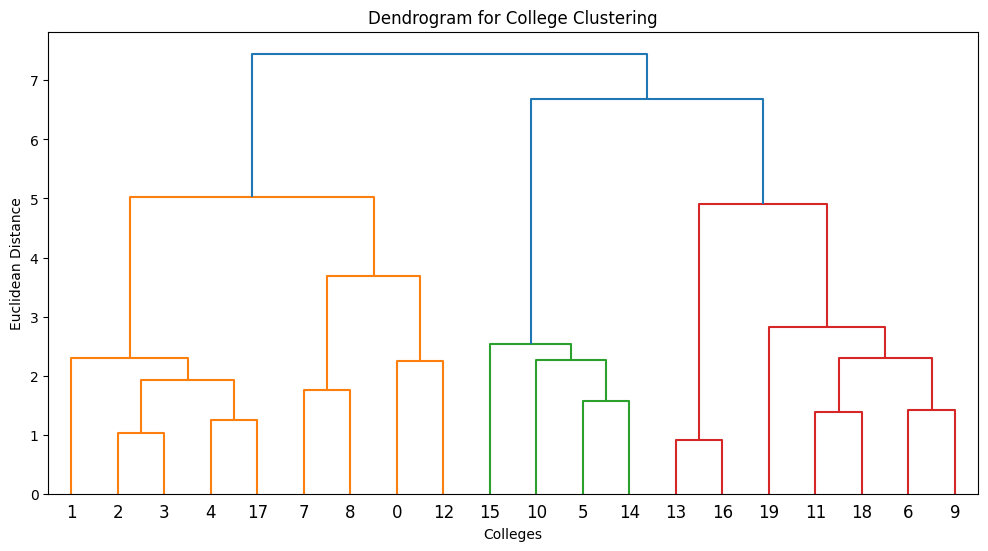

In [7]:
test_X = X_scaled.head(20)
plt.figure(figsize=(12,6))
dendrogram = sch.dendrogram(sch.linkage(test_X, method='ward'))
plt.title("Dendrogram for College Clustering")
plt.xlabel("Colleges")
plt.ylabel("Euclidean Distance")
plt.show()

### Step 2: Apply Agglomerative Clustering(Based on dendrogram, assume 3 clusters)

In [5]:
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
hc

,n_clusters,3
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [6]:
clusters = hc.fit_predict(X_scaled)
clusters

array([2, 0, 0, 0, 0, 0, 1, 0, 2, 1, 0, 1, 0, 2, 0, 0, 2, 0, 1, 1, 0, 2,
       2, 0, 1, 0, 0, 0, 0, 0, 0, 2, 1, 2, 2, 0, 1, 0, 2, 1, 0, 1, 0, 0,
       2, 0, 1, 0, 0, 0, 0, 1, 0, 2, 0, 0, 2, 0, 0, 2, 2, 2, 0, 0, 2, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 2,
       0, 2, 2, 2, 0, 0, 0, 0, 0, 2, 1, 2, 2, 1, 0, 0, 2, 2, 0, 1, 1, 2,
       0, 2, 1, 0, 0, 0, 0, 1, 2, 0, 0, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 2, 2, 2, 2, 0, 0, 2, 0, 1, 0, 0, 2, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 1, 0, 2, 1, 0, 0, 0, 0,
       2, 0, 0, 1, 1, 2, 0, 2, 1, 0, 1, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 2, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 2, 2,
       0, 0, 2, 2, 1, 0, 0, 0, 1, 0, 1, 0, 0, 2, 0, 1, 1, 1, 0, 2, 0, 0,
       1, 0, 0, 1, 0, 0, 2, 1, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 2, 0, 0, 1, 0, 0, 0, 2, 0, 1, 0, 0, 1, 0,

### Clustering is DONE here. Let's put this back to the original Dataset for further Data Mining Operations

### ============================================================

## LEVEL 2: Attach Clusters to Dataset

### 1. Attach Clusters to Dataset

In [7]:
college_data["College_Level"] = clusters
college_data.head(10)

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8,2
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7,0
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9,0
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8,0
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9,0
5,Government College of Technology Coimbatore - ...,28,226582,45,9.32,4,0
6,SSN College of Engineering - Campus 1,14,195983,93,4.51,3,1
7,SRM Institute of Science and Technology - Camp...,26,220103,88,8.33,9,0
8,VIT Vellore - Campus 1,18,249798,69,6.94,9,2
9,SASTRA University - Campus 1,18,168429,95,7.73,4,1


### 2. Data Understanding - Analyze Clusters

In [17]:
college_data[college_data["College_Level"] == 0]

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7,0
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9,0
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8,0
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9,0
5,Government College of Technology Coimbatore - ...,28,226582,45,9.32,4,0
...,...,...,...,...,...,...,...
494,Kumaraguru College of Technology - Campus 17,11,34324,73,11.40,3,0
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5,0
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7,0
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6,0


In [ ]:
# college_data.groupby(by="College_Level").agg(['mean'])

TypeError: agg function failed [how->mean,dtype->object]

### We did some Mistake here. What is that?

### =============================================================

## We had that categorical column and we were not able to take mean for the complete Dataset

In [34]:
college_data

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8,2
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7,0
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9,0
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8,0
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9,0
...,...,...,...,...,...,...,...
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5,0
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7,0
497,Sri Krishna College of Engineering and Technol...,16,199182,64,3.88,3,1
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6,0


In [21]:
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,14,113042,59,9.20,8
1,27,115999,67,3.07,7
2,22,47955,50,3.40,9
3,18,67841,43,4.64,8
4,15,100640,54,4.66,9
...,...,...,...,...,...
495,17,106323,56,9.33,5
496,12,39111,76,3.62,7
497,16,199182,64,3.88,3
498,10,46389,77,9.31,6


In [8]:
X["College_Level"] = clusters
X.head(10)

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level
0,14,113042,59,9.20,8,2
1,27,115999,67,3.07,7,0
2,22,47955,50,3.40,9,0
3,18,67841,43,4.64,8,0
4,15,100640,54,4.66,9,0
5,28,226582,45,9.32,4,0
6,14,195983,93,4.51,3,1
7,26,220103,88,8.33,9,0
8,18,249798,69,6.94,9,2
9,18,168429,95,7.73,4,1


In [35]:
X.groupby(by="College_Level").agg(['mean'])

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
,mean,mean,mean,mean,mean
College_Level,,,,,
0,20.407051,121853.471154,67.278846,6.954583,6.509615
1,17.159091,156795.136364,85.568182,5.565682,3.965909
2,11.650000,175656.000000,59.790000,8.362500,6.080000


In [36]:
X.groupby(by="College_Level").agg(['min','max'])

Student_Faculty_Ratio     Annual_Fees_INR          \
                                min max             min     max   
College_Level                                                     
0                                 8  29           30404  249536   
1                                 8  29           39337  248803   
2                                 8  20           49065  249930   

              Placement_Percentage     Average_Package_LPA         \
                               min max                 min    max   
College_Level                                                       
0                               40  99                2.00  11.99   
1                               64  99                2.09  11.96   
2                               40  99                2.01  11.91   

              Infrastructure_Score      
                               min max  
College_Level                           
0                                3   9  
1                                3   9  
2                                3   9

In [9]:
cluster_names = {1: "Best Colleges",
                 2: "Mid-Level Colleges",
                 0: "Emerging / Lower-Level Colleges"}

X["Category"] = X["College_Level"].map(cluster_names)

In [10]:
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level,Category
0,14,113042,59,9.20,8,2,Mid-Level Colleges
1,27,115999,67,3.07,7,0,Emerging / Lower-Level Colleges
2,22,47955,50,3.40,9,0,Emerging / Lower-Level Colleges
3,18,67841,43,4.64,8,0,Emerging / Lower-Level Colleges
4,15,100640,54,4.66,9,0,Emerging / Lower-Level Colleges
...,...,...,...,...,...,...,...
495,17,106323,56,9.33,5,0,Emerging / Lower-Level Colleges
496,12,39111,76,3.62,7,0,Emerging / Lower-Level Colleges
497,16,199182,64,3.88,3,1,Best Colleges
498,10,46389,77,9.31,6,0,Emerging / Lower-Level Colleges


### ============================================================

## LEVEL 3: Now it's time to Transition to Supervised Learning

In [11]:
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level,Category
0,14,113042,59,9.20,8,2,Mid-Level Colleges
1,27,115999,67,3.07,7,0,Emerging / Lower-Level Colleges
2,22,47955,50,3.40,9,0,Emerging / Lower-Level Colleges
3,18,67841,43,4.64,8,0,Emerging / Lower-Level Colleges
4,15,100640,54,4.66,9,0,Emerging / Lower-Level Colleges
...,...,...,...,...,...,...,...
495,17,106323,56,9.33,5,0,Emerging / Lower-Level Colleges
496,12,39111,76,3.62,7,0,Emerging / Lower-Level Colleges
497,16,199182,64,3.88,3,1,Best Colleges
498,10,46389,77,9.31,6,0,Emerging / Lower-Level Colleges


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Features & Target
input_data  = X.drop(["Category","College_Level"], axis=1)
output_data = X["College_Level"]

# Split
X_train, X_test, y_train, y_test = train_test_split(input_data, output_data, test_size=0.2, random_state=42,stratify = output_data)

# Train Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Accuracy
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.93


### Take the model out to add in the backend

In [31]:
import pickle

pickle.dump(model, open("college_category_model.pkl", "wb"))

### The END!!